## Notebook for identifying TF communities in the Norman dataset

In [1]:
# set up
import math
import pickle
import os

import anndata
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import false_discovery_control, norm
from sklearn.mixture import GaussianMixture

from gcrl.grn import (
    build_cluster_gene_sets,
    build_coassociation_matrix,
    build_tf_tf_cotarget_layer,
    build_tf_tf_regulatory_layer,
    community_stats,
    compute_go_levels,
    consensus_partition_from_coassoc,
    extract_go_ids_from_terms,
    filter_cluster_specific_terms,
    filter_gene_sets_by_size_and_level,
    filter_trivial_partitions,
    partition_stability_diagnostics,
    plot_enrichment_dotplot,
    plot_tf_tf_communities,
    prettify_go_term,
    run_ora_for_clusters,
    run_single_layer_leiden_cot,
    run_single_layer_leiden_reg,
)


In [12]:
# Control parameters
data_folder       = '../../../data/real/Joung2023/'   # path to data folder
results_folder    = '../../../data/real/Joung2023/GRN/'  # path to results folder
figures_folder    = results_folder + 'figures/'        # output folder for saved plots
significance_level = 0.05   # FDR threshold for GRN edge filtering
min_size          = 5       # minimum cluster size (smaller clusters are merged)
top_percentage    = 0.795     # fraction of top-ranked edges to retain

# 3. Hyperparameter grids (tune as needed)
# NOTE: Using ONLY g_reg (regulatory layer), NO cotarget layer
gamma_reg_list = [1.0, 1.1, 1.2, 1.25, 1.3, 1.4, 1.5]
n_seeds = 100

In [ ]:
# HVG universe for ORA: the 5,000 most variable genes used to build the GRN.
# Loaded once here so it is available throughout the notebook.
adata     = anndata.read_h5ad(data_folder + 'Joung2023.h5ad')
hvg_names = list(adata.var_names)  # all 5,000 HVGs
del adata  # free memory; only the gene names are needed

# Helper: save a figure as PNG and SVG, then display it
os.makedirs(figures_folder, exist_ok=True)

def save_figure(fig, name):
    """Save fig to figures_folder as <name>.png and <name>.svg, then show."""
    fig.savefig(figures_folder + name + '.png', dpi=150, bbox_inches='tight')
    fig.savefig(figures_folder + name + '.svg', bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_folder}{name}.png / .svg')


### Loading and filtering GRN

In [6]:
#Load GRN 
raw_grn = pd.read_csv(data_folder + 'GRN/' + "raw_GRN.csv", index_col=0)

#Drop NA values in p-value column
raw_grn = raw_grn.dropna(subset=["p"])

#FDR filtering and only leaving adj p-values values less than 0.05
raw_grn.loc[:, 'adjp'] = false_discovery_control(raw_grn['p'].values, method='bh')
filtered_grn = raw_grn[raw_grn['adjp'] <= significance_level].copy()

# Sort by absolute coefficient descending
filtered_grn = filtered_grn.sort_values(by='coef_abs', ascending=False).reset_index(drop=True)


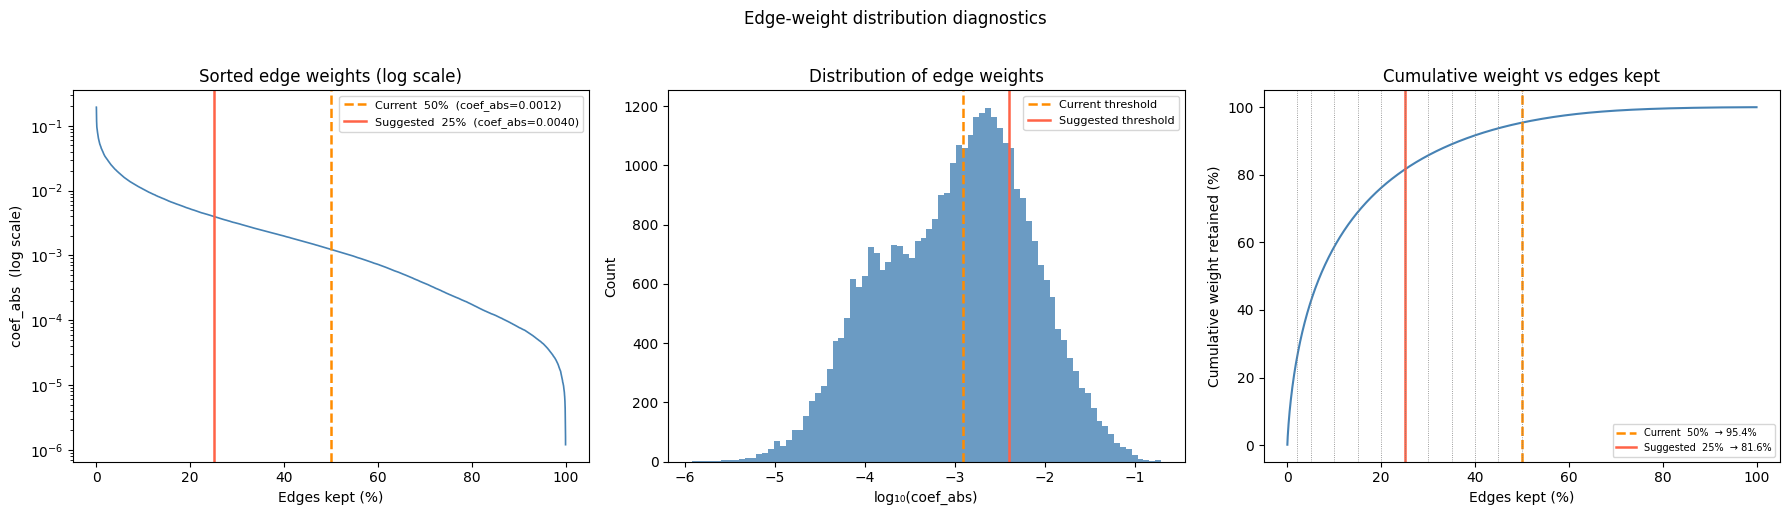

Saved: ../../../data/real/Joung2023/GRN/figures/edge_weight_diagnostics.png / .svg
   Threshold   N edges    coef_abs ≥   Cumul. weight    Δ weight
--------------------------------------------------------------------
          2%       709        0.0326           25.5%           —
          5%      1774        0.0183           42.5%      +17.1%
         10%      3548        0.0105           58.7%      +16.2%
         15%      5323        0.0071           68.9%      +10.2%
         20%      7097        0.0052           76.1%       +7.2%
         25%      8872        0.0040           81.6%       +5.4%  ← suggested
         30%     10646        0.0031           85.7%       +4.2%
         35%     12421        0.0025           89.0%       +3.3%
         40%     14195        0.0020           91.7%       +2.6%
         45%     15970        0.0016           93.8%       +2.1%
         50%     17744        0.0012           95.4%       +1.7%

Suggested top_percentage = 0.25  (first step where Δ c

In [7]:
# Edge-weight threshold diagnostics
# -----------------------------------
# GRN edge-weight distributions are typically heavy-tailed: the diagonal-distance
# elbow on the raw curve always snaps to the very first steep drop and is not useful.
# Instead we show three complementary views to help choose top_percentage:
#
#   1. Log-scale sorted weights  – reveals natural breaks / slope changes in the tail
#   2. Histogram of log10(coef_abs) – shows the shape of the distribution
#   3. Cumulative % of total weight retained vs edges kept – balances coverage vs sparsity

weights_sorted = filtered_grn['coef_abs'].values   # already sorted descending
n = len(weights_sorted)
pct_axis = np.linspace(0, 100, n)
cum_weight = np.cumsum(weights_sorted) / weights_sorted.sum() * 100

# Candidate thresholds and their cumulative weight
candidates = [0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
cw_vals = [cum_weight[int(p * n) - 1] for p in candidates]

# Find the first candidate where the cumulative weight gain over the previous step < 5%
suggested_pct = candidates[-1]
for i in range(1, len(candidates)):
    if cw_vals[i] - cw_vals[i - 1] < 5.0:
        suggested_pct = candidates[i - 1]
        break

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Log-scale sorted weights ---
axes[0].semilogy(pct_axis, weights_sorted, color='steelblue', lw=1.2)
axes[0].axvline(top_percentage * 100, color='darkorange', lw=1.8, linestyle='--',
                label=f'Current  {top_percentage*100:.0f}%'
                      f'  (coef_abs={weights_sorted[int(top_percentage*n)-1]:.4f})')
axes[0].axvline(suggested_pct * 100, color='tomato', lw=1.8, linestyle='-',
                label=f'Suggested  {suggested_pct*100:.0f}%'
                      f'  (coef_abs={weights_sorted[int(suggested_pct*n)-1]:.4f})')
axes[0].set_xlabel('Edges kept (%)')
axes[0].set_ylabel('coef_abs  (log scale)')
axes[0].set_title('Sorted edge weights (log scale)')
axes[0].legend(fontsize=8)

# --- 2. Histogram of log10(coef_abs) ---
log_w = np.log10(weights_sorted[weights_sorted > 0])
axes[1].hist(log_w, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(np.log10(weights_sorted[int(top_percentage * n) - 1]),
                color='darkorange', lw=1.8, linestyle='--', label='Current threshold')
axes[1].axvline(np.log10(weights_sorted[int(suggested_pct * n) - 1]),
                color='tomato', lw=1.8, linestyle='-', label='Suggested threshold')
axes[1].set_xlabel('log₁₀(coef_abs)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of edge weights')
axes[1].legend(fontsize=8)

# --- 3. Cumulative weight with gain bars ---
axes[2].plot(pct_axis, cum_weight, color='steelblue', lw=1.5)
axes[2].axvline(top_percentage * 100, color='darkorange', lw=1.8, linestyle='--',
                label=f'Current  {top_percentage*100:.0f}%  → {cum_weight[int(top_percentage*n)-1]:.1f}%')
axes[2].axvline(suggested_pct * 100, color='tomato', lw=1.8, linestyle='-',
                label=f'Suggested  {suggested_pct*100:.0f}%  → {cum_weight[int(suggested_pct*n)-1]:.1f}%')
for pct in candidates:
    idx = int(pct * n) - 1
    axes[2].axvline(pct * 100, color='gray', lw=0.6, linestyle=':')
axes[2].set_xlabel('Edges kept (%)')
axes[2].set_ylabel('Cumulative weight retained (%)')
axes[2].set_title('Cumulative weight vs edges kept')
axes[2].legend(fontsize=7)

plt.suptitle('Edge-weight distribution diagnostics', y=1.02)
plt.tight_layout()
save_figure(fig, 'edge_weight_diagnostics')

# Summary table
print(f"{'Threshold':>12}  {'N edges':>8}  {'coef_abs ≥':>12}  {'Cumul. weight':>14}  {'Δ weight':>10}")
print("-" * 68)
for i, pct in enumerate(candidates):
    idx = max(0, int(pct * n) - 1)
    delta = f"{cw_vals[i] - cw_vals[i-1]:+.1f}%" if i > 0 else "    —"
    marker = "  ← suggested" if pct == suggested_pct else ""
    print(f"{pct*100:>11.0f}%  {idx+1:>8d}  {weights_sorted[idx]:>12.4f}  "
          f"{cw_vals[i]:>13.1f}%  {delta:>10}{marker}")

print(f"\nSuggested top_percentage = {suggested_pct}"
      f"  (first step where Δ cumulative weight < 5%)")

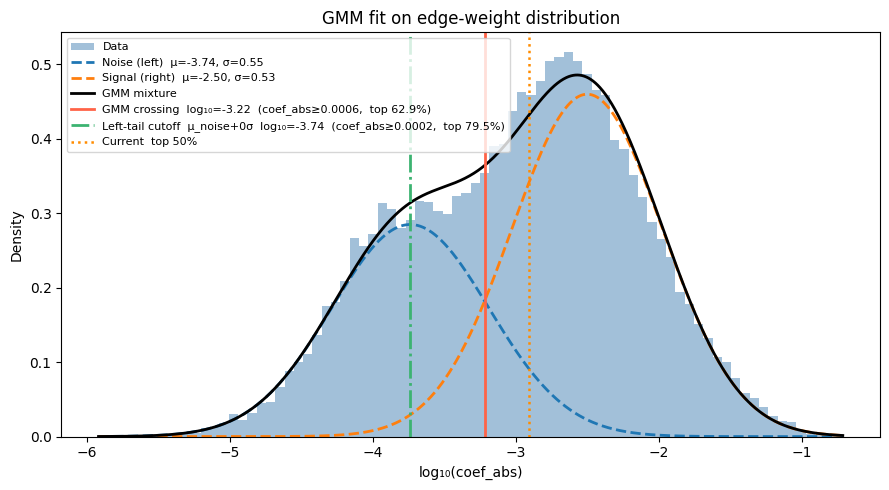

Saved: ../../../data/real/Joung2023/GRN/figures/gmm_threshold.png / .svg
GMM crossing      → coef_abs ≥ 0.0006  (top 62.9%,  22331 edges)
Left-tail cutoff  → coef_abs ≥ 0.0002  (top 79.5%,  28229 edges)  [noise μ - 0σ = -3.74 - 0×0.55]
Current setting   → coef_abs ≥ 0.0012  (top 50%,  17744 edges)


In [8]:
# GMM threshold: fit 2 Gaussians on log10(coef_abs), find the crossing point
# ---------------------------------------------------------------------------
# Two thresholds are computed:
#   1. GMM crossing  : where signal PDF overtakes noise PDF (between the two means).
#      Keeps only edges that are more likely signal than noise.
#   2. Left-tail cutoff: mean of the noise Gaussian + n_sigma * std.
#      Removes only the very weakest edges (deep left tail of the noise component).
#      More permissive than the crossing — useful as a soft floor before ORA.

n_sigma_tail = 0  # how many std above the noise mean to set the left-tail cutoff

log_w = np.log10(weights_sorted[weights_sorted > 0])

# Fit 2-component GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(log_w.reshape(-1, 1))

# Sort components by mean so component 0 = noise (left), 1 = signal (right)
order = np.argsort(gmm.means_.ravel())
means  = gmm.means_.ravel()[order]
stds   = np.sqrt(gmm.covariances_.ravel())[order]
weights_gmm = gmm.weights_[order]

# --- Threshold 1: crossing point between the two weighted Gaussians ---
# Solve: w0 * N(x; mu0, s0) = w1 * N(x; mu1, s1)  on a fine grid
x_grid = np.linspace(log_w.min(), log_w.max(), 10_000)
pdf0 = weights_gmm[0] * norm.pdf(x_grid, means[0], stds[0])
pdf1 = weights_gmm[1] * norm.pdf(x_grid, means[1], stds[1])

# Crossing between the two means = the valley
between = (x_grid > means[0]) & (x_grid < means[1])
diff = pdf1[between] - pdf0[between]
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    cross_log = x_grid[between][sign_changes[0]]
else:
    cross_log = x_grid[between][np.argmin(pdf0[between] + pdf1[between])]

cross_coef = 10 ** cross_log
gmm_pct = np.mean(weights_sorted >= cross_coef)
gmm_n   = int(gmm_pct * n)

# --- Threshold 2: left-tail cutoff (noise mean + n_sigma * noise std) ---
# This excludes only the deepest left tail of the noise component.
tail_log  = means[0] - n_sigma_tail * stds[0]
tail_coef = 10 ** tail_log
tail_pct  = np.mean(weights_sorted >= tail_coef)
tail_n    = int(tail_pct * n)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(log_w, bins=80, density=True, color='steelblue', alpha=0.5,
        edgecolor='none', label='Data')

x_plot = np.linspace(log_w.min(), log_w.max(), 1000)
for i, (m, s, w, lbl) in enumerate(zip(means, stds, weights_gmm,
                                        ['Noise (left)', 'Signal (right)'])):
    ax.plot(x_plot, w * norm.pdf(x_plot, m, s),
            lw=2, linestyle='--', label=f'{lbl}  μ={m:.2f}, σ={s:.2f}')

ax.plot(x_plot, (weights_gmm[0] * norm.pdf(x_plot, means[0], stds[0]) +
                 weights_gmm[1] * norm.pdf(x_plot, means[1], stds[1])),
        lw=2, color='black', label='GMM mixture')

ax.axvline(cross_log, color='tomato', lw=2, linestyle='-',
           label=f'GMM crossing  log₁₀={cross_log:.2f}'
                 f'  (coef_abs≥{cross_coef:.4f},  top {gmm_pct*100:.1f}%)')
ax.axvline(tail_log, color='mediumseagreen', lw=2, linestyle='-.',
           label=f'Left-tail cutoff  μ_noise+{n_sigma_tail}σ  log₁₀={tail_log:.2f}'
                 f'  (coef_abs≥{tail_coef:.4f},  top {tail_pct*100:.1f}%)')
ax.axvline(np.log10(weights_sorted[int(top_percentage * n) - 1]),
           color='darkorange', lw=1.8, linestyle=':',
           label=f'Current  top {top_percentage*100:.0f}%')

ax.set_xlabel('log₁₀(coef_abs)')
ax.set_ylabel('Density')
ax.set_title('GMM fit on edge-weight distribution')
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'gmm_threshold')

print(f"GMM crossing      → coef_abs ≥ {cross_coef:.4f}  "
      f"(top {gmm_pct*100:.1f}%,  {gmm_n} edges)")
print(f"Left-tail cutoff  → coef_abs ≥ {tail_coef:.4f}  "
      f"(top {tail_pct*100:.1f}%,  {tail_n} edges)  "
      f"[noise μ - {n_sigma_tail}σ = {means[0]:.2f} - {n_sigma_tail}×{stds[0]:.2f}]")
print(f"Current setting   → coef_abs ≥ {weights_sorted[int(top_percentage*n)-1]:.4f}  "
      f"(top {top_percentage*100:.0f}%,  {int(top_percentage*n)} edges)")


In [13]:
# selecting top_percentage of top edges
num_top_edges = math.ceil(len(filtered_grn) * top_percentage)
current_grn = filtered_grn.iloc[:num_top_edges, :]

# print statistics
print(current_grn['source'].nunique(), current_grn['target'].nunique())
current_grn

131 1787


,source,target,coef_mean,coef_abs,p,-logp,adjp
0,GLI2,HIST1H2AG,0.193853,0.193853,5.202677e-14,13.283773,1.298159e-12
1,FOXO3,HIST1H4E,0.193276,0.193276,1.555301e-18,17.808186,6.808407e-16
2,ZNF423,ACTB,0.182859,0.182859,1.295317e-15,14.887624,8.188101e-14
3,BCL11A,HIST1H1B,0.180409,0.180409,1.004103e-11,10.998222,8.885321e-11
4,RORA,PTMA,0.180113,0.180113,9.362744e-15,14.028597,3.491647e-13
...,...,...,...,...,...,...,...
28209,HES7,PAX2,-0.000183,0.000183,4.091174e-04,3.388152,6.207078e-04
28210,MAFB,MIR3680-1,-0.000183,0.000183,1.391439e-08,7.856536,4.621253e-08
28211,NEUROG1,MYT1,-0.000183,0.000183,1.757589e-02,1.755083,2.211225e-02
28212,ELF1,TMEM173,-0.000183,0.000183,1.761370e-05,4.754149,3.212703e-05


In [14]:
# Coverage diagnostics: how much of the original GRN survives thresholding?
# -------------------------------------------------------------------------
_before = filtered_grn
_after  = current_grn

n_edges_before   = len(_before)
n_edges_after    = len(_after)
n_tf_src_before  = _before['source'].nunique()
n_tf_src_after   = _after['source'].nunique()
n_target_before  = _before['target'].nunique()
n_target_after   = _after['target'].nunique()
n_unique_genes_before = pd.concat([_before['source'], _before['target']]).nunique()
n_unique_genes_after  = pd.concat([_after['source'],  _after['target']]).nunique()

print(f"{'Metric':<35} {'Before':>10} {'After':>10} {'Retained':>10}")
print("-" * 67)
print(f"{'Edges':<35} {n_edges_before:>10,} {n_edges_after:>10,} {n_edges_after/n_edges_before:>9.1%}")
print(f"{'TF sources':<35} {n_tf_src_before:>10,} {n_tf_src_after:>10,} {n_tf_src_after/n_tf_src_before:>9.1%}")
print(f"{'Target genes':<35} {n_target_before:>10,} {n_target_after:>10,} {n_target_after/n_target_before:>9.1%}")
print(f"{'Unique genes (src + tgt)':<35} {n_unique_genes_before:>10,} {n_unique_genes_after:>10,} {n_unique_genes_after/n_unique_genes_before:>9.1%}")
print()
print(f"top_percentage = {top_percentage}  →  keeping {n_edges_after:,} / {n_edges_before:,} edges")
print(f"Target gene coverage: {n_target_after:,} / {n_target_before:,}  "
      f"({'good' if n_target_after/n_target_before > 0.6 else 'WARNING: low — consider raising top_percentage'})")


Metric                                  Before      After   Retained
-------------------------------------------------------------------
Edges                                   35,489     28,214     79.5%
TF sources                                 131        131    100.0%
Target genes                             1,906      1,787     93.8%
Unique genes (src + tgt)                 1,909      1,795     94.0%

top_percentage = 0.795  →  keeping 28,214 / 35,489 edges
Target gene coverage: 1,787 / 1,906  (good)


In [15]:
# Save all genes present in the thresholded GRN (sources + targets)
all_genes = sorted(
    set(current_grn['source']).union(current_grn['target'])
)
with open(results_folder + 'all_genes.txt', 'w') as f:
    f.write('\n'.join(all_genes))
print(f'Saved {len(all_genes):,} genes → {results_folder}all_genes.txt')


Saved 1,795 genes → ../../../data/real/Joung2023/GRN/all_genes.txt


### Retrieving the list of TFs

In [16]:
# Load TF reference
tf_info = pd.read_parquet(data_folder + 'GRN/' + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet") ## Google Drive: gCAL_data > Norman_results
tf_names = list(tf_info.columns.unique())
tf_names = [item for item in tf_names if item in current_grn['source'].unique() or item in current_grn['target'].unique()]
print(f"Number of TFs in reference: {len(tf_names)}")

Number of TFs in reference: 131


## Initial assessments

In [17]:
# 1. Build layers
g_reg, tf_index = build_tf_tf_regulatory_layer(current_grn, tf_names)
g_cot, sim_matrix = build_tf_tf_cotarget_layer(current_grn, tf_names, tf_index, min_similarity=0.15)
print('Number of edges in g_reg: ', g_reg.ecount())
print('Number of edges in g_cot: ', g_cot.ecount())

# 2. computing memberships
mem_reg, _, _ = run_single_layer_leiden_reg(g_reg, gamma_reg=1.2, seed=0)
mem_cot, _, _ = run_single_layer_leiden_cot(g_cot, gamma_cot=1.2, seed=0)

# 3. computing community statistics
print(community_stats(g_reg, mem_reg).head(n=10))
print(community_stats(g_reg, mem_reg).shape)
print(community_stats(g_cot, mem_cot).head(n=10))
print(community_stats(g_cot, mem_cot).shape)


Number of edges in g_reg:  1950
Number of edges in g_cot:  1814
   community  size  w_internal   density
1          0    31    0.528077  0.001136
0          3    16    0.256113  0.002134
4          2    16    0.517399  0.004312
7          1    16    0.345098  0.002876
5          4    15    0.120740  0.001150
6          6    10    0.211550  0.004701
2          5    10    0.271204  0.006027
8          7     9    0.089288  0.002480
3          8     8    0.078115  0.002790
(9, 4)
   community  size  w_internal   density
0          0    26   38.185499  0.117494
5          1    22   34.026542  0.147301
2          3    16   21.990979  0.183258
3          2    16   18.012071  0.150101
6          4    14   12.405676  0.136326
4          5    13    7.632300  0.097850
7          6    11   11.542353  0.209861
1          7     8    5.516462  0.197017
8          8     3    1.427563  0.475854
9          9     1    0.000000  0.000000
(11, 4)


In [18]:
# 3. Sweep & collect partitions using single-layer clustering on g_reg only
results = {}
for gamma_reg in gamma_reg_list:
    key = gamma_reg
    memberships = []
    for seed in range(n_seeds):
        mem, _, _ = run_single_layer_leiden_reg(g_reg, gamma_reg=gamma_reg, seed=seed)
        memberships.append(mem)
    results[key] = memberships
    print(f'Done γ_reg={gamma_reg}')


Done γ_reg=1.0
Done γ_reg=1.1
Done γ_reg=1.2
Done γ_reg=1.25
Done γ_reg=1.3
Done γ_reg=1.4
Done γ_reg=1.5


In [19]:
# 4. Filter trivial partitions for each hyperparameter combination
filtered_results = {}
for key, memberships in results.items():
    filtered, n_removed = filter_trivial_partitions(
        memberships,
        min_clusters=3,          # At least 3 clusters
        max_cluster_ratio=0.5,   # No more than 50% of nodes as separate clusters
        min_mean_size=3.0,       # Average cluster size >= 3 TFs
        verbose=True
    )
    filtered_results[key] = filtered
    print(f"{key}: kept {len(filtered)}/{len(memberships)} partitions (removed {n_removed})")

# 5. Compute stability on filtered results
stability = {}
for key, membs in filtered_results.items():
    if len(membs) < 2:
        print(f"Skipping {key}: too few valid partitions after filtering")
        continue

    summary, aris, vis = partition_stability_diagnostics(
        membs,
        compute_ari=True,
        max_pairs=200
    )
    stability[key] = summary
    print(f"{key}: VI_mean={summary['VI_mean']:.3f}, ARI_mean={summary['ARI_mean']:.3f}")


Removed 0 trivial partitions out of 100 (0.0%)
1.0: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.1: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.2: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.25: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.3: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.4: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.5: kept 100/100 partitions (removed 0)
1.0: VI_mean=1.512, ARI_mean=0.449
1.1: VI_mean=1.463, ARI_mean=0.495
1.2: VI_mean=1.351, ARI_mean=0.550
1.25: VI_mean=1.166, ARI_mean=0.617
1.3: VI_mean=1.076, ARI_mean=0.642
1.4: VI_mean=0.870, ARI_mean=0.707
1.5: VI_mean=0.835, ARI_mean=0.720


In [20]:
# saving results and stability summaries for later analysis
with open(results_folder + "filtered_results.pkl", "wb") as f:
    pickle.dump(filtered_results, f)
with open(results_folder + "stability.pkl", "wb") as f:
    pickle.dump(stability, f)
#with open(results_folder + "filtered_results.pkl", "rb") as f:
#    filtered_results = pickle.load(f)
#with open(results_folder + "stability.pkl", "rb") as f:
#    stability = pickle.load(f)


In [21]:
# Pick the most stable gamma_reg (lowest VI_mean)
best_key = min(stability.items(), key=lambda kv: kv[1]['VI_mean'])[0]
print("Best hyperparams (gamma_reg):", best_key)
print("Best stability stats:", stability[best_key])

# 6. Consensus clustering for best hyperparams
memberships_list = filtered_results[best_key]
C = build_coassociation_matrix(memberships_list)
consensus_labels, consensus_graph = consensus_partition_from_coassoc(
    C, min_coassoc=0.5, resolution=1.5
)

# 7. Diagnostics for g_reg layer only
df_reg_stats = community_stats(g_reg, consensus_labels)

print("Regulatory layer community stats:")
print(df_reg_stats)


Best hyperparams (gamma_reg): 1.5
Best stability stats: {'VI_mean': np.float64(0.8354643380917678), 'VI_std': np.float64(0.5048908545053838), 'ARI_mean': np.float64(0.7203742624129432), 'ARI_std': np.float64(0.1757703152495379), 'n_pairs': 200}
Regulatory layer community stats:
    community  size  w_internal   density
5           0    23    0.277972  0.001099
0           1    15    0.245153  0.002335
4           3    14    0.383045  0.004209
1           2    14    0.173254  0.001904
9           4    11    0.083487  0.001518
6           5     9    0.178605  0.004961
7           6     9    0.078991  0.002194
2           7     8    0.050879  0.001817
3           9     8    0.078115  0.002790
8           8     8    0.083559  0.002984
11         10     7    0.258497  0.012309
10         11     5    0.192448  0.019245


In [23]:
# Count elements per cluster
counts = pd.DataFrame({"consensus_labels": consensus_labels})["consensus_labels"].value_counts().to_dict()

# Identify small clusters
small_clusters = {lab for lab, cnt in counts.items() if cnt < min_size}

if small_clusters:
    min_label = int(np.min(np.array(list(small_clusters))))
    consensus_labels = np.where(np.isin(consensus_labels, list(small_clusters)), min_label, consensus_labels)
    print(f"Merged {len(small_clusters)} small cluster(s) into label {min_label}")
else:
    print("No small clusters to merge.")

# Diagnostics for g_reg layer only
df_reg_stats = community_stats(g_reg, consensus_labels)

print("Regulatory layer community stats after merging small clusters:")
print(df_reg_stats)

No small clusters to merge.
Regulatory layer community stats after merging small clusters:
    community  size  w_internal   density
5           0    23    0.277972  0.001099
0           1    15    0.245153  0.002335
4           3    14    0.383045  0.004209
1           2    14    0.173254  0.001904
9           4    11    0.083487  0.001518
6           5     9    0.178605  0.004961
7           6     9    0.078991  0.002194
2           7     8    0.050879  0.001817
3           9     8    0.078115  0.002790
8           8     8    0.083559  0.002984
11         10     7    0.258497  0.012309
10         11     5    0.192448  0.019245


In [24]:
# saving 
with open(results_folder + "consensus_labels.pkl", "wb") as f:
    pickle.dump(consensus_labels, f)

In [25]:
# Save TF community assignments
tf_communities = pd.DataFrame({
    'community': consensus_labels,
    'tf': tf_names,
}).sort_values(['community', 'tf']).reset_index(drop=True)

fname = f'tf_communities_{int(top_percentage * 100)}pct.csv'
tf_communities.to_csv(results_folder + fname, index=False)
print(f'Saved {len(tf_communities)} TFs → {results_folder}{fname}')
print(tf_communities.groupby('community').size().rename('n_tfs').to_string())


Saved 131 TFs → ../../../data/real/Joung2023/GRN/tf_communities_79pct.csv
community
0     23
1     15
2     14
3     14
4     11
5      9
6      9
7      8
8      8
9      8
10     7
11     5


## Network visualization

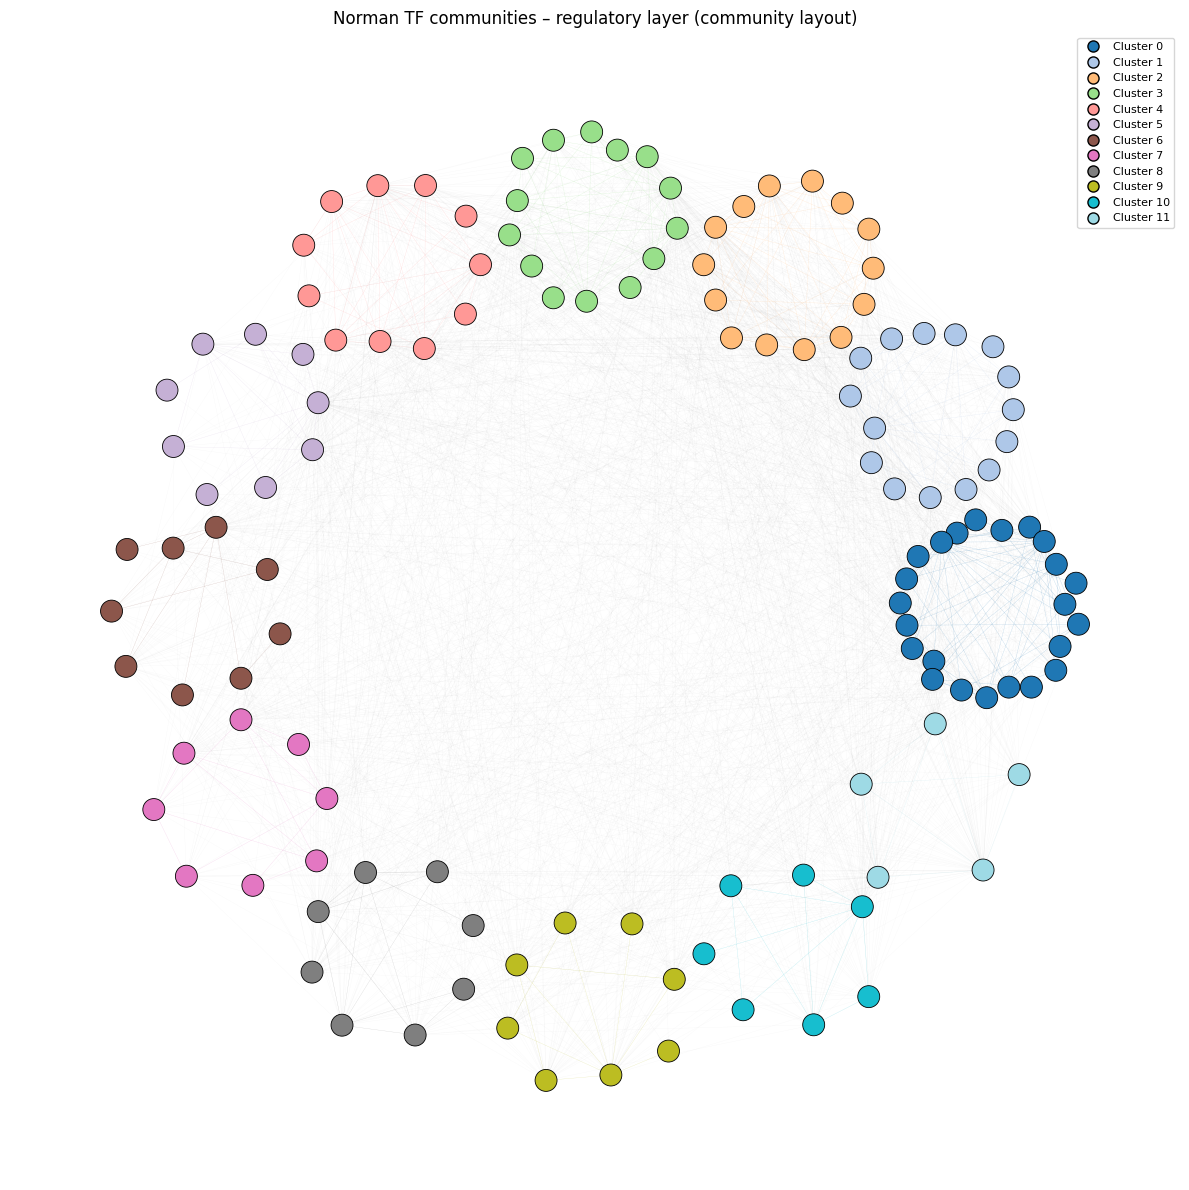

Saved: ../../../data/real/Joung2023/GRN/figures/tf_communities_overview.png / .svg


In [26]:
# Overview: community-aware layout, no labels
G_vis, pos_vis = plot_tf_tf_communities(
    current_grn=current_grn,
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    layout='community',
    k=0.7,
    seed=42,
    figsize=(12, 12),
    node_size=250,
    with_labels=False,
    edge_alpha_intra=0.35,
    edge_alpha_inter=0.08,
    edge_width_scale=2.0,
    title='Norman TF communities – regulatory layer (community layout)',
    show=False,
)
save_figure(plt.gcf(), 'tf_communities_overview')


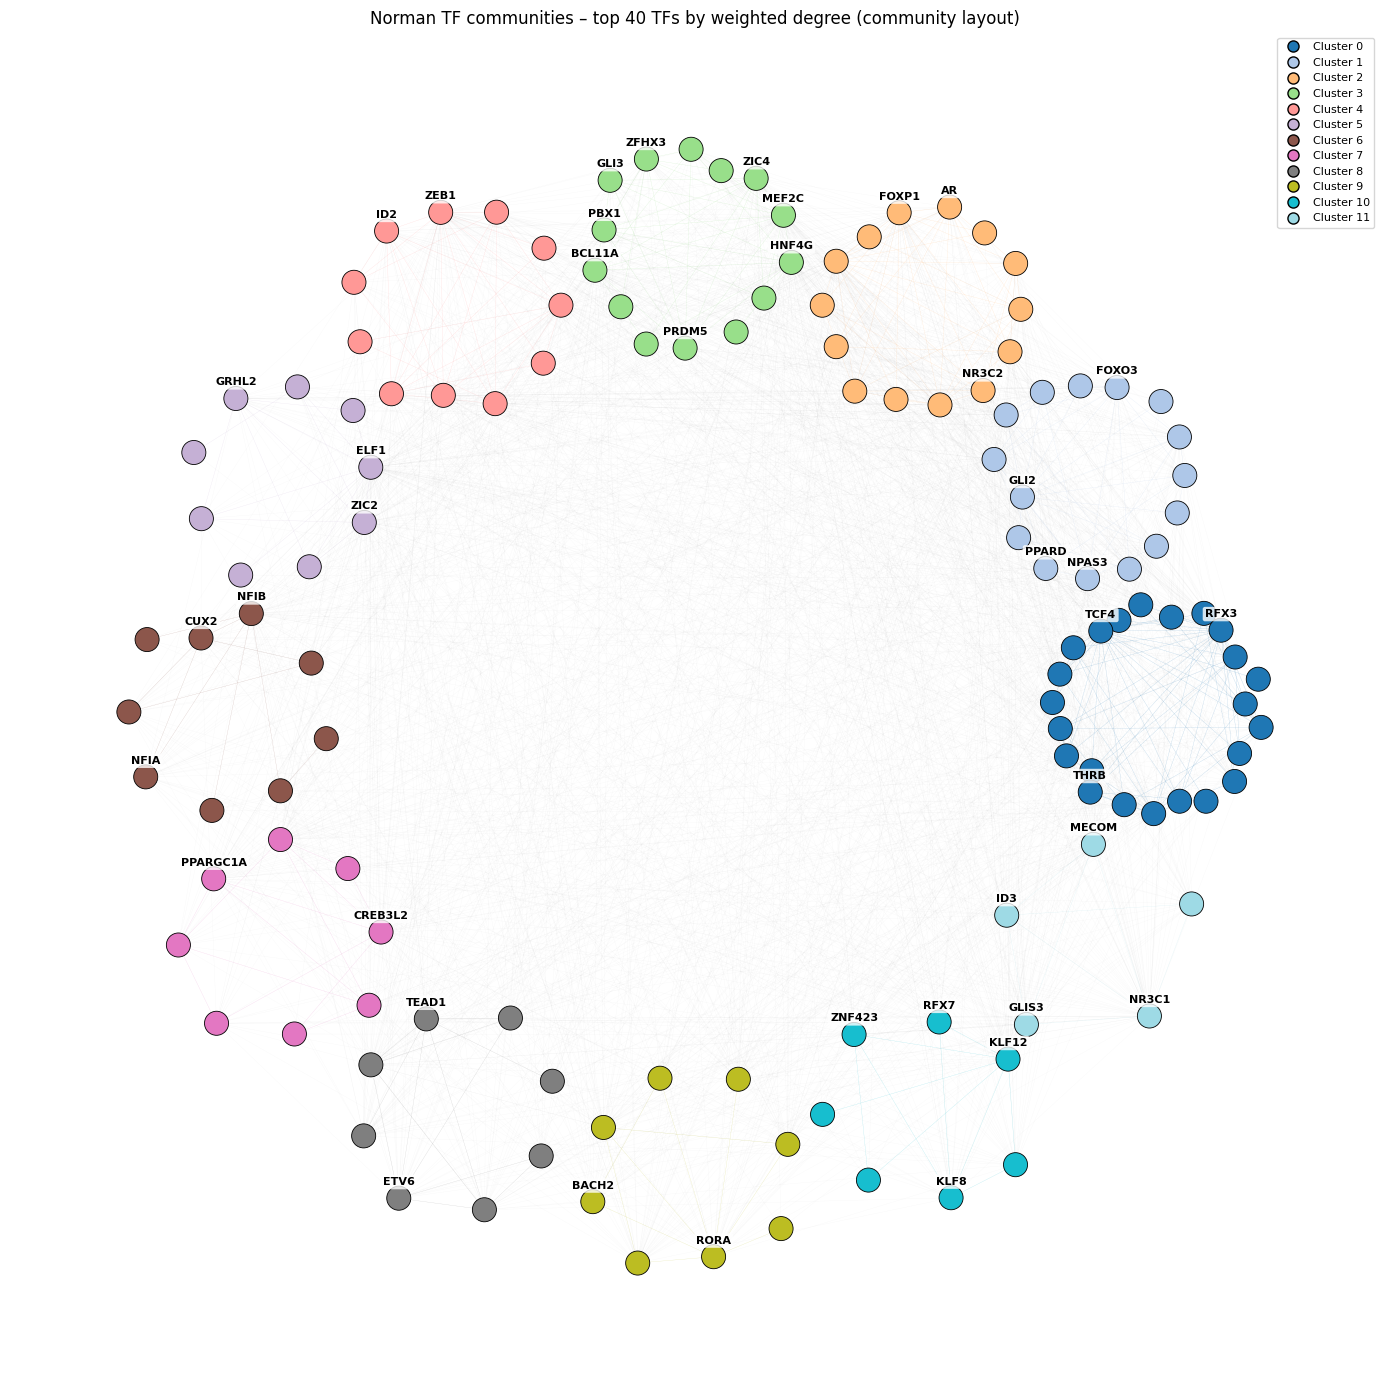

Saved: ../../../data/real/Joung2023/GRN/figures/tf_communities_labeled.png / .svg


In [27]:
# Labeled view: top 40 TFs by weighted degree
G_vis, pos_vis = plot_tf_tf_communities(
    current_grn=current_grn,
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    layout='community',
    k=0.7,
    seed=42,
    figsize=(14, 14),
    node_size=300,
    with_labels=False,
    label_top_n_degree=40,
    edge_alpha_intra=0.35,
    edge_alpha_inter=0.08,
    edge_width_scale=2.0,
    title='Norman TF communities – top 40 TFs by weighted degree (community layout)',
    show=False,
)
save_figure(plt.gcf(), 'tf_communities_labeled')


## Gene set enrichment analysis

In [28]:
# 1) Build per-cluster gene sets (TFs + targets)
cluster2genes = build_cluster_gene_sets(
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    current_grn=current_grn,
)

# 2) Load GO BP gene sets (Homo sapiens)
raw_go_bp = gp.get_library(name='GO_Biological_Process_2025', organism='Human')

# 2.1) Extract GO IDs present in this library
go_ids_in_library = extract_go_ids_from_terms(raw_go_bp)

# 2.2) Compute levels only for these GO IDs (BP namespace)
# Note: go_obo_path is optional - defaults to gCRL/data/reference/ontologies/go-basic.obo
go_term_levels = compute_go_levels(
    go_ids=go_ids_in_library,
    namespace="biological_process",
)

Loading GO DAG from /home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/data/reference/ontologies/go-basic.obo ...
/home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/data/reference/ontologies/go-basic.obo: fmt(1.2) rel(2025-10-10) 42,666 Terms


In [29]:
# 3) Filter GO BP by size and (optionally) level
go_bp_filtered = filter_gene_sets_by_size_and_level(
    gene_sets=raw_go_bp,
    min_size=20,               # min genes per GO term
    max_size=200,              # max genes per GO term
    go_term_levels=go_term_levels,
    min_level=5,               # example: only level >= 4
    max_level=None,            # or e.g. 5 if you want 4–5 only
)
len(go_bp_filtered)

1484

In [30]:
# 4) Run ORA
# universe_mode controls the background population N for the hypergeometric test:
#   'grn'    — GRN genes only (~700): biologically precise, but can be too small
#              when cluster gene-sets cover >50% of the universe (BH kills all results)
#   'custom' — arbitrary gene list via custom_universe= (recommended: pass hvg_names,
#              the 5,000 HVGs — larger than GRN, smaller than GO library,
#              and tied to the genes actually measured in this experiment)
#   'go'     — all GO library genes (~11k): maximum power but inflates
#              housekeeping terms (e.g. myeloid/erythroid differentiation in K562)
ora_results = run_ora_for_clusters(
    cluster2genes=cluster2genes,
    gene_sets=go_bp_filtered,
    universe_mode='go',
    custom_universe=hvg_names,
    min_genes_in_cluster=5,
)

print(f'Total ORA rows: {len(ora_results)}')
print(f'Rows with FDR < 0.05: {(ora_results["pval_adj"] < 0.05).sum()}')
print(f'Clusters with ≥1 significant term: {sorted(ora_results[ora_results["pval_adj"] < 0.05]["cluster_id"].unique())}')


Universe mode: 'go'  →  N = 11,748 genes
Total ORA rows: 13941
Rows with FDR < 0.05: 921
Clusters with ≥1 significant term: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


In [31]:
# 5) Flag cell-line background terms
# Terms significantly enriched in >50% of clusters are likely K562 housekeeping
# biology (e.g. myeloid/erythroid differentiation), not cluster-specific signal.
ora_results = filter_cluster_specific_terms(
    ora_results,
    fdr_threshold=0.05,
    max_cluster_fraction=0.5,
)

bg_terms = ora_results[ora_results['background_term']]['go_term'].unique()
print(f'Flagged background terms ({len(bg_terms)}):')
for t in sorted(bg_terms):
    print(f'  {prettify_go_term(t)}')

# Retain only cluster-specific terms for downstream analysis
filtered_ora_results = ora_results[~ora_results['background_term']].copy()

# 5) Save results
ora_results.to_csv(results_folder + 'tf_cluster_GO_BP_ORA_results.csv', index=False)
with open(results_folder + 'tf_cluster_GO_BP_ORA_results.pkl', 'wb') as f:
    pickle.dump(ora_results, f)

filter_cluster_specific_terms: 12 clusters, FDR < 0.05, max_cluster_fraction = 0.5
  → 70 background terms flagged (significant in > 50% of clusters)
  → 13,101 rows retained
Flagged background terms (70):
  + Reg of Phosphatidylinositol 3-Kinase/Prot Kinase B Signal Transduction
  Adherens Junction Organization
  Anterograde Trans-Synaptic Signaling
  Axon Guidance
  Axonogenesis
  Blood Vessel Endothelial Cell Migration
  Calcium Ion Transmembrane Import Into Cytosol
  Cardiac Conduction
  Cell Junction Assembly
  Cell Migration Involved in Sprouting Angiogenesis
  Cell-Cell Junction Organization
  Cellular Response to Calcium Ion
  Central Nervous System Neuron Differentiation
  Chordate Embryonic Development
  Collagen Fibril Organization
  Embryonic Skeletal System Development
  Ephrin Receptor Signaling Pathway
  Extracellular Matrix Organization
  Generation of Neurons
  Inhibitory Synapse Assembly
  Metal Ion Transport
  Modulation of Chemical Synaptic Transmission
  Negative R

In [32]:
# For each cluster, show top 5 enriched GO BP terms
for cluster_id in filtered_ora_results['cluster_id'].unique():
    print(f"\nCluster {cluster_id} top GO BP terms:")
    top_terms = filtered_ora_results[filtered_ora_results['cluster_id'] == cluster_id].sort_values(by='pval').head(10)
    for _, row in top_terms.iterrows():
        print(f"  {row['go_term']} (P-value: {row['pval']:.4e}), adj p-value: {row['pval_adj']:.4e})")


Cluster 0 top GO BP terms:
  Embryonic Skeletal System Morphogenesis (GO:0048704) (P-value: 2.5263e-04), adj p-value: 7.5112e-03)
  Regulation of Neurotransmitter Secretion (GO:0046928) (P-value: 3.1428e-04), adj p-value: 8.5743e-03)
  Axon Extension (GO:0048675) (P-value: 3.2015e-04), adj p-value: 8.5743e-03)
  Negative Regulation of Wnt Signaling Pathway (GO:0030178) (P-value: 3.2356e-04), adj p-value: 8.5743e-03)
  Primary Neural Tube Formation (GO:0014020) (P-value: 3.9400e-04), adj p-value: 9.6057e-03)
  Negative Regulation of Cell Projection Organization (GO:0031345) (P-value: 5.0201e-04), adj p-value: 1.1173e-02)
  Camera-Type Eye Development (GO:0043010) (P-value: 5.1215e-04), adj p-value: 1.1173e-02)
  Embryonic Limb Morphogenesis (GO:0030326) (P-value: 5.1327e-04), adj p-value: 1.1173e-02)
  Neural Tube Closure (GO:0001843) (P-value: 6.5742e-04), adj p-value: 1.3583e-02)
  Apoptotic Cell Clearance (GO:0043277) (P-value: 7.9674e-04), adj p-value: 1.4942e-02)

Cluster 1 top GO

### GO enrichment dotplots

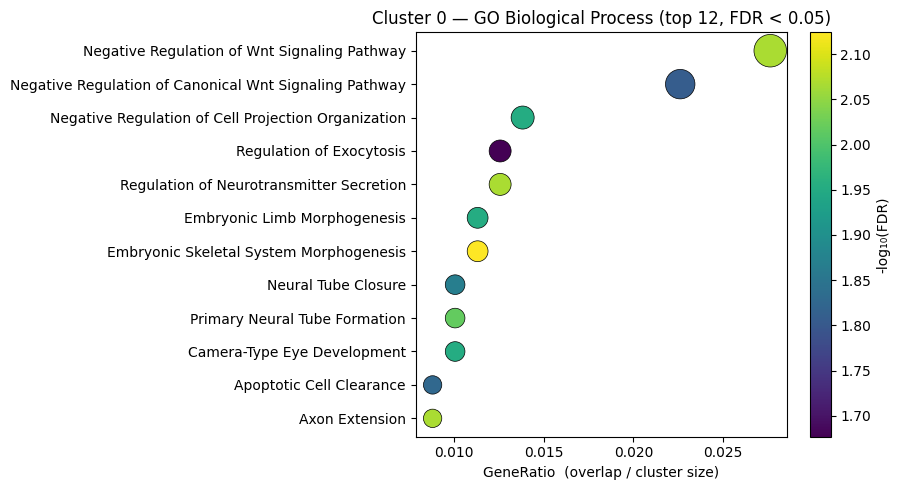

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_0.png / .svg


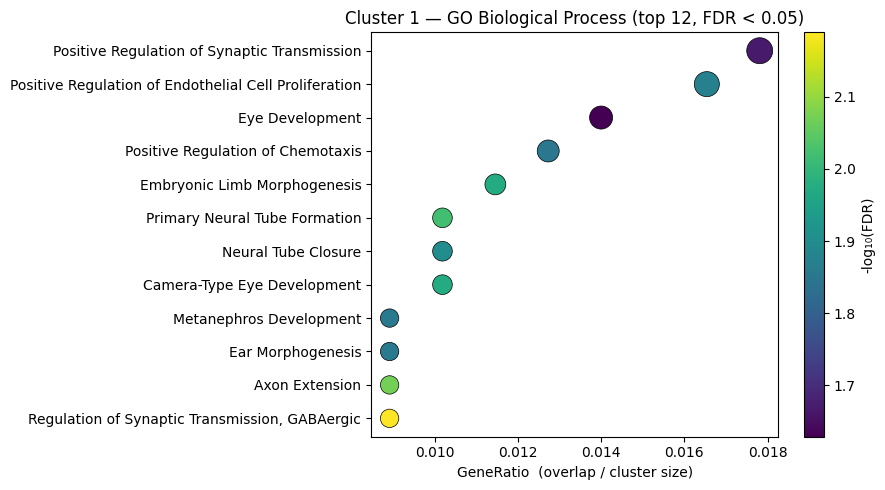

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_1.png / .svg


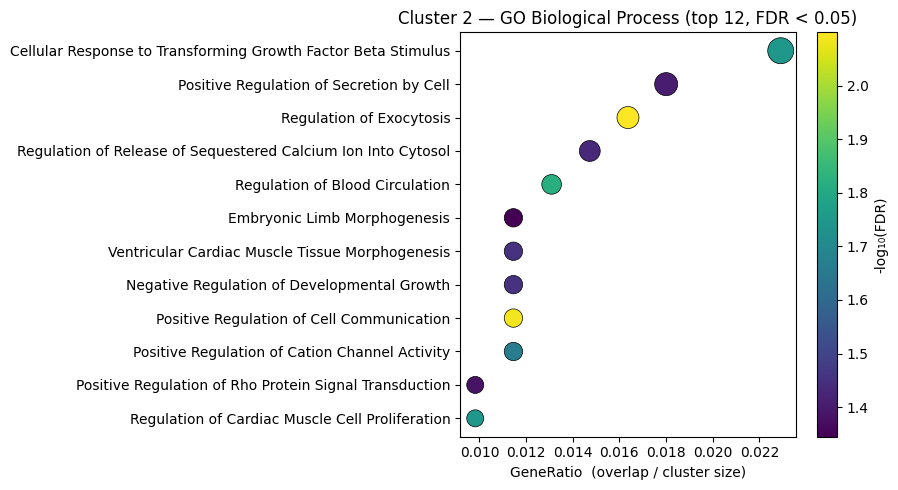

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_2.png / .svg


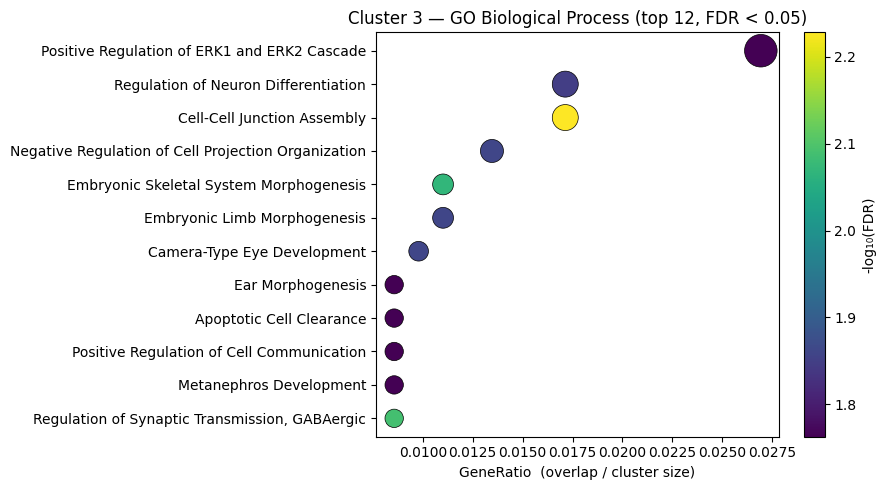

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_3.png / .svg


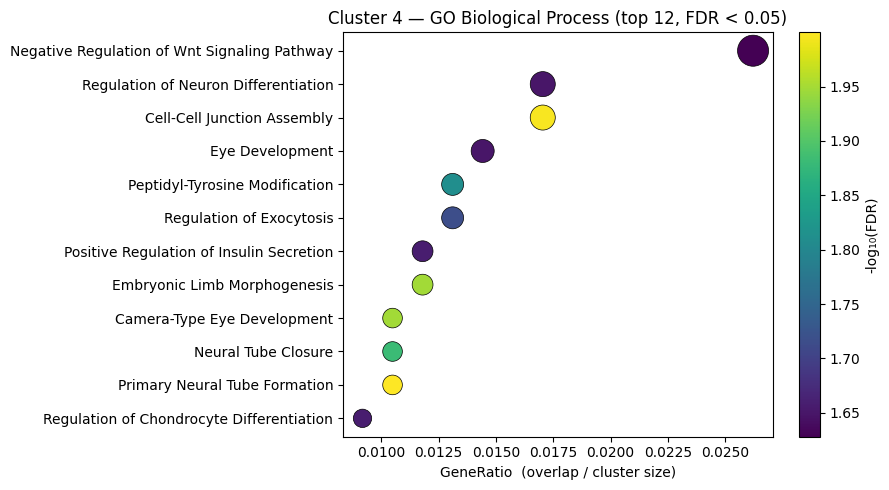

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_4.png / .svg


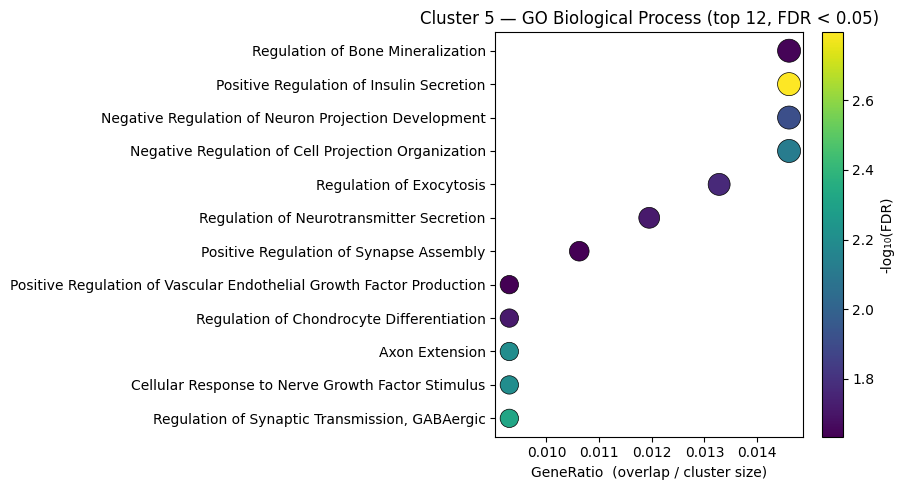

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_5.png / .svg


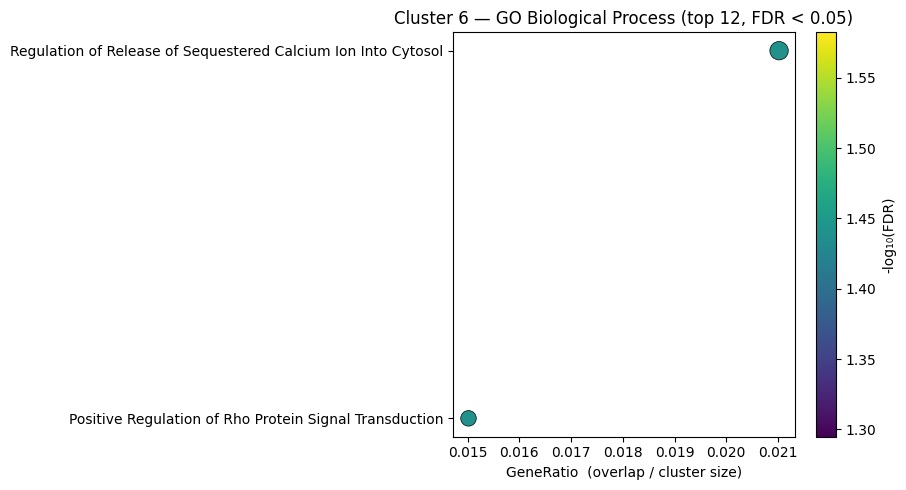

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_6.png / .svg


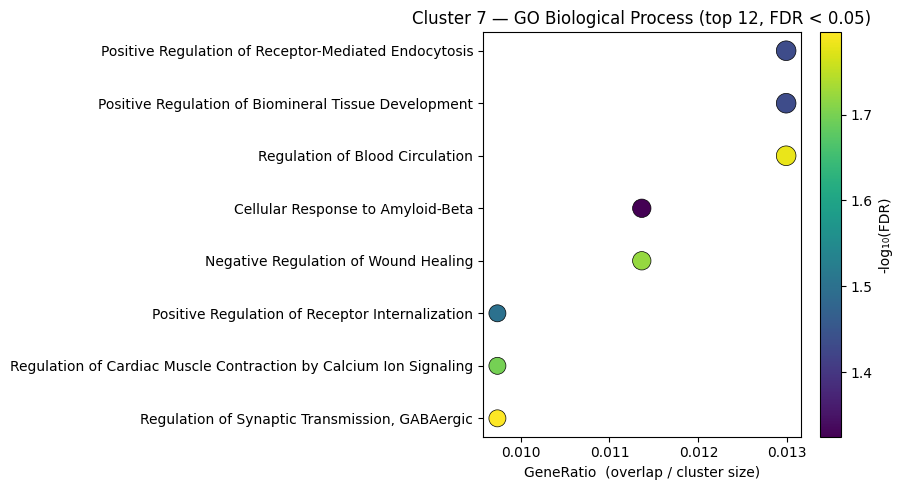

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_7.png / .svg


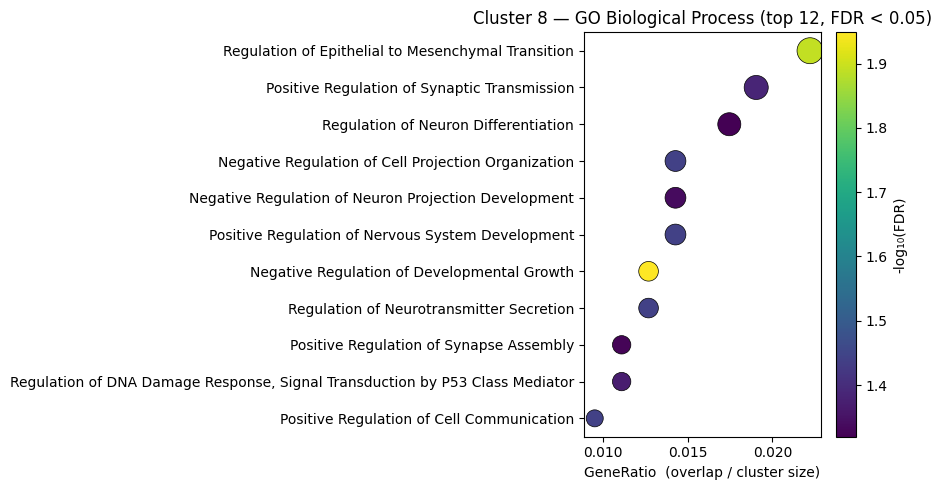

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_8.png / .svg


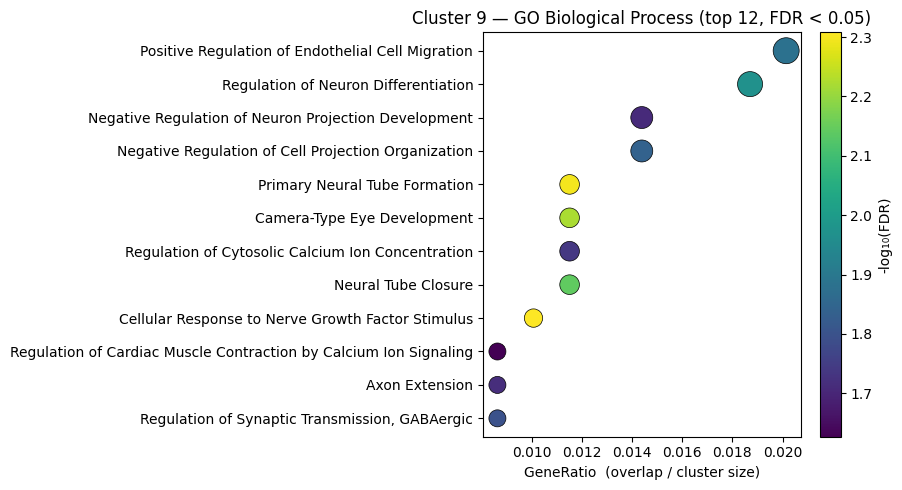

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_9.png / .svg


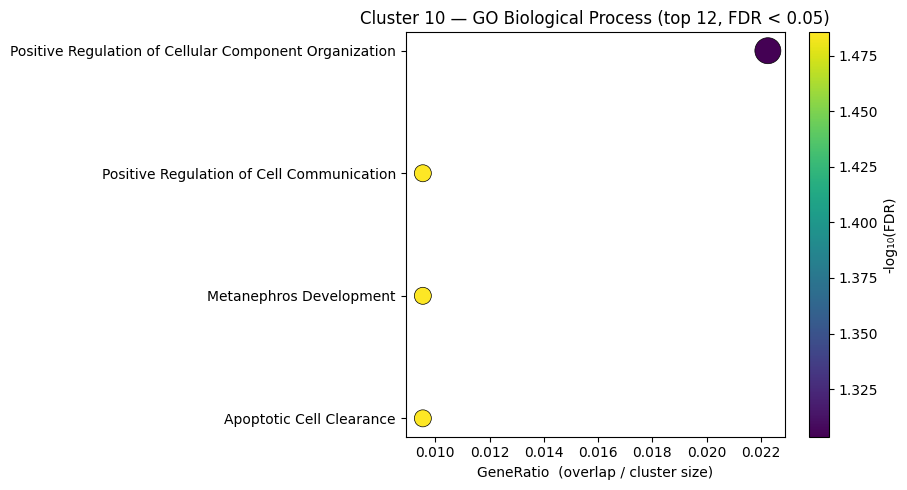

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_10.png / .svg


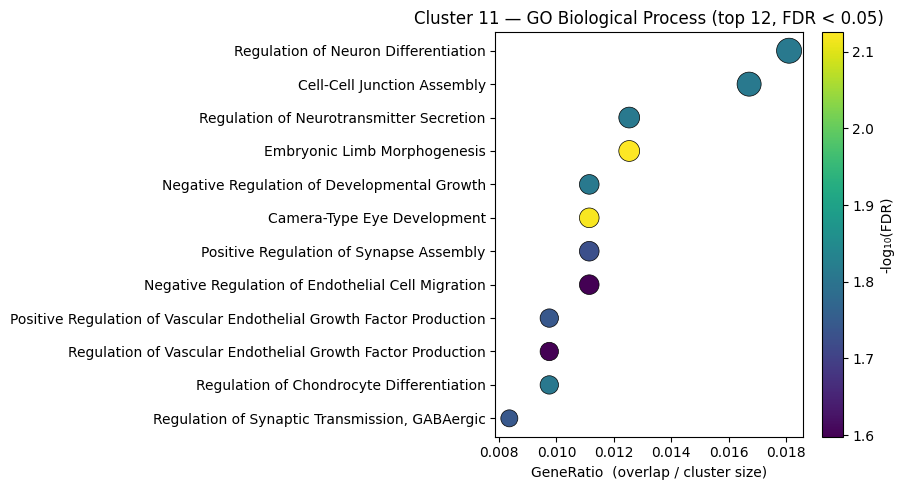

Saved: ../../../data/real/Joung2023/GRN/figures/dotplot_cluster_11.png / .svg


In [33]:
# One dotplot per cluster (significant, cluster-specific terms only)
sig_results = filtered_ora_results[(filtered_ora_results['pval_adj'] < 0.05)]

for cluster_id in sorted(sig_results['cluster_id'].unique()):
    n_terms = (sig_results['cluster_id'] == cluster_id).sum()
    if n_terms == 0:
        continue
    fig, ax = plot_enrichment_dotplot(
        enrich_df=sig_results,
        cluster_id=cluster_id,
        top_n=12,
        term_parser=prettify_go_term,
        figsize=(9, 5),
        title=f'Cluster {cluster_id} — GO Biological Process (top 12, FDR < 0.05)',
        show=False,
    )
    save_figure(fig, f'dotplot_cluster_{cluster_id}')
